In [ ]:
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from unet_diffusion_model import noiser

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

full_dataset = datasets.CIFAR10(
    "./dataset", train=True, download=True, transform=transform
)
train_set, val_set = random_split(full_dataset, [0.8, 0.2])
test_set = datasets.CIFAR10("./dataset", train=False, download=True)


def get_dataloaders():
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_set, batch_size=64, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_set, batch_size=64, shuffle=True, drop_last=True)
    return train_loader, val_loader, test_loader

c:\Users\fakef\Documents\Dev\unet-diffusion-model\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [15]:
def show_tensor(tensor, zoom=8):
    # Clamp to valid range, convert CHW → HWC, scale to uint8
    img_array = tensor.clamp(0, 1).permute(1, 2, 0).numpy()
    img_array = (img_array * 255).astype(np.uint8)
    img = Image.fromarray(img_array)
    display(img.resize((img.width * zoom, img.height * zoom), Image.NEAREST))

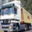

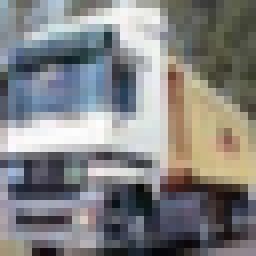

In [19]:
show_tensor(full_dataset[1][0], zoom=1)
show_tensor(full_dataset[1][0], zoom=8)

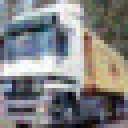

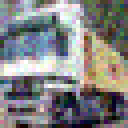

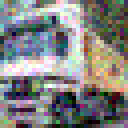

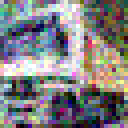

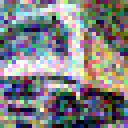

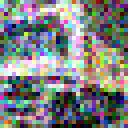

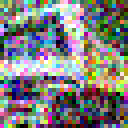

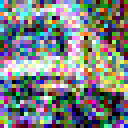

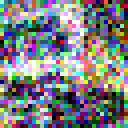

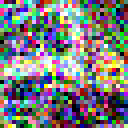

In [ ]:
img = full_dataset[1][0]
betas, alpha_bars = noiser.linear_noise_schedule(10e-4, 0.02, 10)

for i in range(10):
    new_image = noiser.q_sample(img, i, alpha_bars)
    show_tensor(new_image[0], zoom=4)